In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import os
import random
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [3]:
PROCESSED_BASE_DIR = "/content/drive/MyDrive/TongueImagediabetes/data/processed_segmented_wb"

DIABETES_DIR = os.path.join(PROCESSED_BASE_DIR, "diabetes")
NONDIABETES_DIR = os.path.join(PROCESSED_BASE_DIR, "nondiabetes")

print("Diabetes dir exists:", os.path.exists(DIABETES_DIR))
print("Non-diabetes dir exists:", os.path.exists(NONDIABETES_DIR))

Diabetes dir exists: True
Non-diabetes dir exists: True


In [4]:
def build_dataframe(diabetes_dir, nondiabetes_dir):
    rows = []

    for img_path in sorted(Path(diabetes_dir).glob("*")):
        if img_path.suffix.lower() in [".png", ".jpg", ".jpeg"]:
            rows.append({
                "image_path": str(img_path),
                "label": 1,
                "label_name": "diabetes"
            })

    for img_path in sorted(Path(nondiabetes_dir).glob("*")):
        if img_path.suffix.lower() in [".png", ".jpg", ".jpeg"]:
            rows.append({
                "image_path": str(img_path),
                "label": 0,
                "label_name": "nondiabetes"
            })

    return pd.DataFrame(rows)

df = build_dataframe(DIABETES_DIR, NONDIABETES_DIR)

print("Total samples:", len(df))
print(df["label_name"].value_counts())
df.head()

Total samples: 954
label_name
nondiabetes    519
diabetes       435
Name: count, dtype: int64


,image_path,label,label_name
0,/content/drive/MyDrive/TongueImagediabetes/dat...,1,diabetes
1,/content/drive/MyDrive/TongueImagediabetes/dat...,1,diabetes
2,/content/drive/MyDrive/TongueImagediabetes/dat...,1,diabetes
3,/content/drive/MyDrive/TongueImagediabetes/dat...,1,diabetes
4,/content/drive/MyDrive/TongueImagediabetes/dat...,1,diabetes


In [5]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

print("\nTrain distribution:")
print(train_df["label_name"].value_counts())

print("\nVal distribution:")
print(val_df["label_name"].value_counts())

print("\nTest distribution:")
print(test_df["label_name"].value_counts())

Train: 667
Val: 143
Test: 144

Train distribution:
label_name
nondiabetes    363
diabetes       304
Name: count, dtype: int64

Val distribution:
label_name
nondiabetes    78
diabetes       65
Name: count, dtype: int64

Test distribution:
label_name
nondiabetes    78
diabetes       66
Name: count, dtype: int64


In [6]:
class TongueDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "image_path"]
        label = self.df.loc[idx, "label"]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


# SAME style as Swin (important for consistency)
transform = transforms.Compose([
    transforms.Resize((256, 256)),  # GAN-friendly size
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)  # [-1, 1] range for GAN
])


train_dataset = TongueDataset(train_df, transform=transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))

Train batches: 21


In [7]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100, num_classes=2, img_channels=3):
        super().__init__()
        self.latent_dim = latent_dim
        self.num_classes = num_classes

        self.label_emb = nn.Embedding(num_classes, num_classes)

        self.init_size = 256 // 16  # 16
        self.fc = nn.Sequential(
            nn.Linear(latent_dim + num_classes, 512 * self.init_size * self.init_size)
        )

        self.conv_blocks = nn.Sequential(
            nn.BatchNorm2d(512),

            nn.Upsample(scale_factor=2),
            nn.Conv2d(512, 256, 3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.Upsample(scale_factor=2),
            nn.Conv2d(256, 128, 3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 64, 3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.Upsample(scale_factor=2),
            nn.Conv2d(64, img_channels, 3, stride=1, padding=1),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        label_input = self.label_emb(labels)
        gen_input = torch.cat((noise, label_input), dim=1)

        out = self.fc(gen_input)
        out = out.view(out.size(0), 512, self.init_size, self.init_size)
        img = self.conv_blocks(out)
        return img


latent_dim = 100
num_classes = 2

generator = Generator(latent_dim=latent_dim, num_classes=num_classes).to(device)
print(generator)

Generator(
  (label_emb): Embedding(2, 2)
  (fc): Sequential(
    (0): Linear(in_features=102, out_features=131072, bias=True)
  )
  (conv_blocks): Sequential(
    (0): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (1): Upsample(scale_factor=2.0, mode='nearest')
    (2): Conv2d(512, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): ReLU(inplace=True)
    (5): Upsample(scale_factor=2.0, mode='nearest')
    (6): Conv2d(256, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): Upsample(scale_factor=2.0, mode='nearest')
    (10): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13)

In [9]:
class Discriminator(nn.Module):
    def __init__(self, num_classes=2, img_channels=3):
        super().__init__()

        def block(in_channels, out_channels, bn=True):
            layers = [
                nn.Conv2d(in_channels, out_channels, 3, stride=2, padding=1),
                nn.LeakyReLU(0.2, inplace=True),
                nn.Dropout2d(0.25)
            ]
            if bn:
                layers.append(nn.BatchNorm2d(out_channels))
            return layers

        self.model = nn.Sequential(
            *block(img_channels, 64, bn=False),
            *block(64, 128),
            *block(128, 256),
            *block(256, 512)
        )

        # downsampled size
        ds_size = 256 // 2**4  # 16

        self.adv_layer = nn.Sequential(
            nn.Linear(512 * ds_size * ds_size, 1),
            nn.Sigmoid()
        )

        self.aux_layer = nn.Sequential(
            nn.Linear(512 * ds_size * ds_size, num_classes),
            nn.Softmax(dim=1)
        )

    def forward(self, img):
        out = self.model(img)
        out = out.view(out.size(0), -1)

        validity = self.adv_layer(out)   # real/fake
        label = self.aux_layer(out)      # class prediction

        return validity, label


discriminator = Discriminator(num_classes=2).to(device)
print(discriminator)

Discriminator(
  (model): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Dropout2d(p=0.25, inplace=False)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Dropout2d(p=0.25, inplace=False)
    (6): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (8): LeakyReLU(negative_slope=0.2, inplace=True)
    (9): Dropout2d(p=0.25, inplace=False)
    (10): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Conv2d(256, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (12): LeakyReLU(negative_slope=0.2, inplace=True)
    (13): Dropout2d(p=0.25, inplace=False)
    (14): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )

In [10]:
adversarial_loss = nn.BCELoss()
auxiliary_loss = nn.CrossEntropyLoss()

optimizer_G = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

print("Losses and optimizers ready.")

Losses and optimizers ready.


In [11]:
latent_dim = 100
sample_interval = 200

real_label_value = 1.0
fake_label_value = 0.0

print("latent_dim:", latent_dim)
print("sample_interval:", sample_interval)

latent_dim: 100
sample_interval: 200


In [21]:
SAVE_DIR = "/content/drive/MyDrive/TongueImagediabetes/data/acgan_outputs"
os.makedirs(SAVE_DIR, exist_ok=True)

In [22]:
num_epochs = 120

for epoch in range(num_epochs):
    for i, (imgs, labels) in enumerate(train_loader):

        batch_size = imgs.size(0)

        real_imgs = imgs.to(device)
        labels = labels.to(device)

        valid = torch.full((batch_size, 1), real_label_value, device=device)
        fake = torch.full((batch_size, 1), fake_label_value, device=device)

        # ---------------------
        #  Train Generator
        # ---------------------
        optimizer_G.zero_grad()

        z = torch.randn(batch_size, latent_dim, device=device)
        gen_labels = torch.randint(0, num_classes, (batch_size,), device=device)

        gen_imgs = generator(z, gen_labels)

        validity, pred_label = discriminator(gen_imgs)

        g_loss = adversarial_loss(validity, valid) + auxiliary_loss(pred_label, gen_labels)

        g_loss.backward()
        optimizer_G.step()

        # ---------------------
        #  Train Discriminator
        # ---------------------
        optimizer_D.zero_grad()

        real_pred, real_aux = discriminator(real_imgs)
        d_real_loss = adversarial_loss(real_pred, valid) + auxiliary_loss(real_aux, labels)

        fake_pred, fake_aux = discriminator(gen_imgs.detach())
        d_fake_loss = adversarial_loss(fake_pred, fake) + auxiliary_loss(fake_aux, gen_labels)

        d_loss = (d_real_loss + d_fake_loss) / 2

        d_loss.backward()
        optimizer_D.step()

        # ---------------------
        #  Logging
        # ---------------------
        if i % 200 == 0:
          with torch.no_grad():
              sample_z = torch.randn(8, latent_dim, device=device)
              sample_labels = torch.tensor([0,0,0,0,1,1,1,1], device=device)

              sample_imgs = generator(sample_z, sample_labels)
              sample_imgs = (sample_imgs + 1) / 2

              save_image(sample_imgs, f"{SAVE_DIR}/epoch_{epoch}_batch_{i}.png", nrow=4)

In [23]:
torch.save(generator.state_dict(), os.path.join(SAVE_DIR, "acgan_generator.pth"))
torch.save(discriminator.state_dict(), os.path.join(SAVE_DIR, "acgan_discriminator.pth"))

print("Saved to:", SAVE_DIR)
print(os.listdir(SAVE_DIR))

Saved to: /content/drive/MyDrive/TongueImagediabetes/data/acgan_outputs
['epoch_0_batch_0.png', 'epoch_1_batch_0.png', 'epoch_2_batch_0.png', 'epoch_3_batch_0.png', 'epoch_4_batch_0.png', 'epoch_5_batch_0.png', 'epoch_6_batch_0.png', 'epoch_7_batch_0.png', 'epoch_8_batch_0.png', 'epoch_9_batch_0.png', 'epoch_10_batch_0.png', 'epoch_11_batch_0.png', 'epoch_12_batch_0.png', 'epoch_13_batch_0.png', 'epoch_14_batch_0.png', 'epoch_15_batch_0.png', 'epoch_16_batch_0.png', 'epoch_17_batch_0.png', 'epoch_18_batch_0.png', 'epoch_19_batch_0.png', 'epoch_20_batch_0.png', 'epoch_21_batch_0.png', 'epoch_22_batch_0.png', 'epoch_23_batch_0.png', 'epoch_24_batch_0.png', 'epoch_25_batch_0.png', 'epoch_26_batch_0.png', 'epoch_27_batch_0.png', 'epoch_28_batch_0.png', 'epoch_29_batch_0.png', 'epoch_30_batch_0.png', 'epoch_31_batch_0.png', 'epoch_32_batch_0.png', 'epoch_33_batch_0.png', 'epoch_34_batch_0.png', 'epoch_35_batch_0.png', 'epoch_36_batch_0.png', 'epoch_37_batch_0.png', 'epoch_38_batch_0.png', '

In [24]:
import os
from torchvision.utils import save_image

GEN_DIR = "/content/drive/MyDrive/TongueImagediabetes/data/acgan_outputs/generated"
os.makedirs(GEN_DIR, exist_ok=True)

generator.eval()

n_samples_per_class = 200

with torch.no_grad():
    for class_label in [0, 1]:  # 0 = nondiabetes, 1 = diabetes

        z = torch.randn(n_samples_per_class, latent_dim, device=device)
        labels = torch.full((n_samples_per_class,), class_label, dtype=torch.long, device=device)

        gen_imgs = generator(z, labels)

        # scale from [-1,1] → [0,1]
        gen_imgs = (gen_imgs + 1) / 2

        for i in range(n_samples_per_class):
            save_path = os.path.join(GEN_DIR, f"class{class_label}_{i}.png")
            save_image(gen_imgs[i], save_path)

print("Generated images saved at:", GEN_DIR)
print("Total generated:", len(os.listdir(GEN_DIR)))

Generated images saved at: /content/drive/MyDrive/TongueImagediabetes/data/acgan_outputs/generated
Total generated: 400


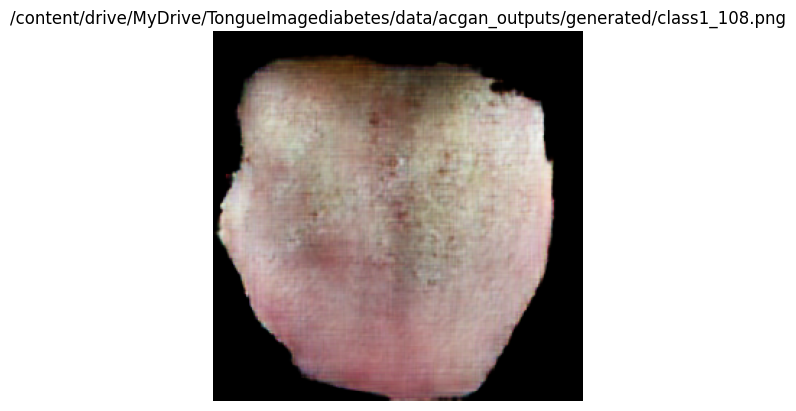

In [41]:
import matplotlib.pyplot as plt
import random

sample_imgs = os.listdir(GEN_DIR)
sample_path = os.path.join(GEN_DIR, random.choice(sample_imgs))

img = Image.open(sample_path)
plt.imshow(img)
plt.title(sample_path)
plt.axis("off")
plt.show()

In [43]:
from pathlib import Path

syn_paths = list(Path(GEN_DIR).glob("*.png"))

syn_rows = []

for p in syn_paths:
    name = p.name

    if "class0_" in name:
        label = 0
        label_name = "nondiabetes"
    elif "class1_" in name:
        label = 1
        label_name = "diabetes"
    else:
        continue

    syn_rows.append({
        "image_path": str(p),
        "label": label,
        "label_name": label_name
    })

syn_df = pd.DataFrame(syn_rows)

print("Synthetic samples:", len(syn_df))
print(syn_df["label_name"].value_counts())

Synthetic samples: 400
label_name
nondiabetes    200
diabetes       200
Name: count, dtype: int64


In [44]:
aug_train_df = pd.concat([train_df, syn_df], ignore_index=True)

print("Original train size:", len(train_df))
print("Synthetic size:", len(syn_df))
print("Augmented train size:", len(aug_train_df))

print("\nAugmented class distribution:")
print(aug_train_df["label_name"].value_counts())

Original train size: 667
Synthetic size: 400
Augmented train size: 1067

Augmented class distribution:
label_name
nondiabetes    563
diabetes       504
Name: count, dtype: int64


In [45]:
AUG_CSV_PATH = "/content/drive/MyDrive/TongueImagediabetes/data/acgan_outputs/aug_train_df.csv"

aug_train_df.to_csv(AUG_CSV_PATH, index=False)

print("Saved:", AUG_CSV_PATH)

Saved: /content/drive/MyDrive/TongueImagediabetes/data/acgan_outputs/aug_train_df.csv
